# GRU vs LSTM Sentiment Analysis

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow. keras.preprocessing. text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense
from sklearn.model_selection import train_test_split

In [2]:
texts = [
"I love deep learning",
"Artificial intelligence is amazing",
"This course is excellent",
"I am very happy today",
"The movie was fantastic",
"I hate this product",
"This is very bad",
"The service was terrible",
"I am disappointed",
"The experience was awful"
]
labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_length = max([len(seq) for seq in sequences])
X = pad_sequences(sequences, maxlen=max_length)
y = np.array(labels)
print(X)
print(y)

[[ 0  1  8  9 10]
 [ 0 11 12  2 13]
 [ 0  3 14  2 15]
 [ 1  6  7 16 17]
 [ 0  4 18  5 19]
 [ 0  1 20  3 21]
 [ 0  3  2  7 22]
 [ 0  4 23  5 24]
 [ 0  0  1  6 25]
 [ 0  4 26  5 27]]
[1 1 1 1 1 0 0 0 0 0]


In [4]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2,random_state=42)

In [111]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

##LSTM

In [5]:
lstm_model=Sequential([
Embedding(
input_dim=len(tokenizer.word_index)+1,
output_dim=16,
input_length=max_length
),
LSTM(64),
Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
lstm_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy' ]
)
lstm_model. summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_lstm=lstm_model.fit(
X_train,
y_train,
epochs=20,
validation_data=(X_test,y_test),
verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7500 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6950
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8750 - loss: 0.6901 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8750 - loss: 0.6892 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8750 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8750 - loss: 0.6873 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8750 - loss: 0.6862 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.6850 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 0.6838 - val_accuracy: 0.5000 - val_loss: 0.6959
Ep

In [8]:
lstm_loss, lstm_acc=lstm_model. evaluate(
X_test,
y_test,
verbose=0)

print(f"LSTM Loss: {lstm_loss: .4f}")
print(f"LSTM Accuracy: {lstm_acc : .4f}")

LSTM Loss:  0.6997
LSTM Accuracy:  0.5000


##GRU Model

In [9]:
gru_model=Sequential([
Embedding(
input_dim=len(tokenizer.word_index)+1,
output_dim=16,
input_length=max_length
),
GRU(32),
Dense(1,activation='sigmoid')
])

In [10]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_gru= gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3750 - loss: 0.6942 - val_accuracy: 0.0000e+00 - val_loss: 0.6947
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.0000e+00 - val_loss: 0.6948
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5000 - loss: 0.6922 - val_accuracy: 0.0000e+00 - val_loss: 0.6950
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6250 - loss: 0.6912 - val_accuracy: 0.0000e+00 - val_loss: 0.6952
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6250 - loss: 0.6902 - val_accuracy: 0.0000e+00 - val_loss: 0.6953
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7500 - loss: 0.6892 - val_accuracy: 0.0000e+00 - val_loss: 0.6955
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7500 - loss: 0.6881 - val_accuracy: 0.0000e+00 - val_loss: 0.6957
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7500 - loss: 0.6870 - val_accuracy:

In [12]:
gru_loss, gru_acc=gru_model. evaluate(
X_test,
y_test,
verbose=0)

print(f"Gru Loss: {gru_loss: .4f}")
print(f"Gru Accuracy: {gru_acc : .4f}")

Gru Loss:  0.6984
Gru Accuracy:  0.5000


In [13]:
print('Model Cpmparision')
print(f'LSTM Loss: {lstm_loss : .4f}')
print(f'LSTM Accuracy: {lstm_acc : .4f}')
print(f'GRU Loss: {gru_loss : .4f}')
print(f'GRU Accuracy: {gru_acc : .4f}')

Model Cpmparision
LSTM Loss:  0.6997
LSTM Accuracy:  0.5000
GRU Loss:  0.6984
GRU Accuracy:  0.5000


In [14]:
def predict_sentiment(model, text):
  seq=tokenizer.texts_to_sequences([text])
  padded=pad_sequences(seq,maxlen=max_length)
  prediction=model.predict(padded,verbose=0)[0][0]
  if prediction>=0.5:
    return 'Positive',prediction
  else:
    return 'Negative',prediction

In [15]:
text="I love artificial Intelligence"
result, score=predict_sentiment(
lstm_model,
text)

print("LSTM Prediction")
print(f"Text:{text}")
print(f"Predicted Sentiment:{result}")
print(f"Confidence Score:{score: .4f}")

LSTM Prediction
Text:I love artificial Intelligence
Predicted Sentiment:Positive
Confidence Score: 0.5161


In [16]:
text="I love artificial Intelligence"
result, score=predict_sentiment(
gru_model,
text)

print("GRU Prediction")
print(f"Text:{text}")
print(f"Predicted Sentiment:{result}")
print(f"Confidence Score:{score: .4f}")

GRU Prediction
Text:I love artificial Intelligence
Predicted Sentiment:Positive
Confidence Score: 0.5083


#IMDB GRU+LSTM+RNN

##Task-1: Dataset Analysis

In [17]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import imdb

In [18]:
# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data()

print("Training Reviews:", len(X_train))
print("Testing Reviews :", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Reviews: 25000
Testing Reviews : 25000


In [19]:
reviews = np.concatenate((X_train, X_test))
labels = np.concatenate((y_train, y_test))

In [20]:
total_reviews = len(reviews)

print("Total Reviews:", total_reviews)

Total Reviews: 50000


In [21]:
positive_count = np.sum(labels == 1)
negative_count = np.sum(labels == 0)

print("Positive Reviews:", positive_count)
print("Negative Reviews:", negative_count)

Positive Reviews: 25000
Negative Reviews: 25000


In [22]:
review_lengths = [len(review) for review in reviews]

In [23]:
avg_length = np.mean(review_lengths)

print("Average Review Length:", round(avg_length, 2))

Average Review Length: 234.76


In [24]:
longest_review = max(review_lengths)

print("Longest Review Length:", longest_review)

Longest Review Length: 2494


In [25]:
shortest_review = min(review_lengths)

print("Shortest Review Length:", shortest_review)

Shortest Review Length: 7


In [26]:
summary = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Positive Reviews",
        "Negative Reviews",
        "Average Length",
        "Longest Review",
        "Shortest Review"
    ],
    "Value": [
        total_reviews,
        positive_count,
        negative_count,
        round(avg_length, 2),
        longest_review,
        shortest_review
    ]
})

print(summary)

             Metric     Value
0     Total Reviews  50000.00
1  Positive Reviews  25000.00
2  Negative Reviews  25000.00
3    Average Length    234.76
4    Longest Review   2494.00
5   Shortest Review      7.00


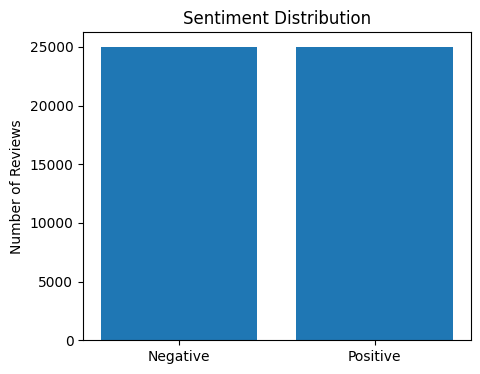

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(['Negative', 'Positive'],
        [negative_count, positive_count])

plt.title("Sentiment Distribution")
plt.ylabel("Number of Reviews")
plt.show()

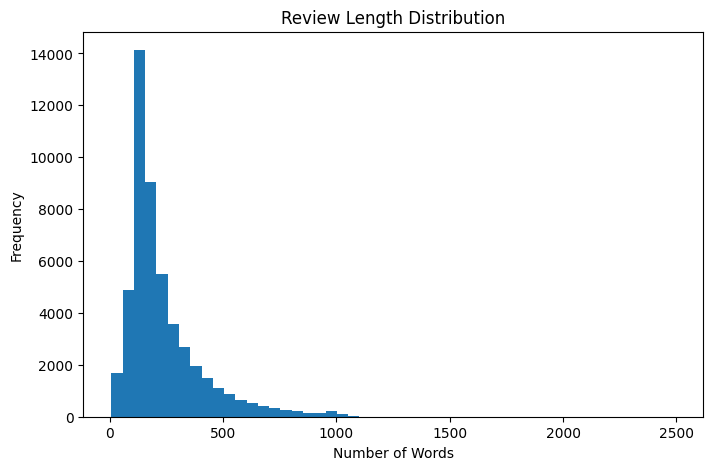

In [28]:
plt.figure(figsize=(8,5))
plt.hist(review_lengths, bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

##Task-2: Text Preprocessing

In [29]:
import re
import string
import numpy as np

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [30]:
from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

word_index = imdb.get_word_index()

reverse_word_index = {
    value: key for key, value in word_index.items()
}

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
def decode_review(encoded_review):

    words = []

    for index in encoded_review:

        if index >= 3:
            word = reverse_word_index.get(index - 3, "?")
            words.append(word)

    return " ".join(words)

In [32]:
sample_review = decode_review(X_train[0])

print(sample_review[:500])

this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and would recommend it to everyone to 


In [33]:
def convert_to_lowercase(text):
    return text.lower()

In [34]:
text = convert_to_lowercase(sample_review)

In [35]:
def remove_html_tags(text):

    clean_text = re.sub(r'<.*?>', '', text)

    return clean_text

In [36]:
text = remove_html_tags(text)

In [37]:
def remove_punctuation(text):

    return text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

In [38]:
text = remove_punctuation(text)

In [39]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [40]:
text = remove_stopwords(text)

In [41]:
def tokenize_text(text):

    return word_tokenize(text)

In [42]:
tokens = tokenize_text(text)

print(tokens[:20])

['film', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyones', 'really', 'suited', 'part', 'played', 'could', 'imagine', 'robert', 'amazing', 'actor', 'director', 'father', 'came']


In [43]:
def preprocess_text(text):

    text = convert_to_lowercase(text)

    text = remove_html_tags(text)

    text = remove_punctuation(text)

    text = remove_stopwords(text)

    tokens = tokenize_text(text)

    return tokens

In [44]:
processed_review = preprocess_text(sample_review)

print(processed_review[:30])

['film', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyones', 'really', 'suited', 'part', 'played', 'could', 'imagine', 'robert', 'amazing', 'actor', 'director', 'father', 'came', 'scottish', 'island', 'loved', 'fact', 'real', 'connection', 'film', 'witty', 'remarks', 'throughout']


In [45]:
processed_reviews = []

for review in X_train[:1000]:

    text = decode_review(review)

    tokens = preprocess_text(text)

    processed_reviews.append(tokens)

In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=VOCAB_SIZE)

texts = [
    " ".join(review)
    for review in processed_reviews
]

tokenizer.fit_on_texts(texts)

In [47]:
sequences = tokenizer.texts_to_sequences(texts)

print(sequences[0][:20])

[3, 404, 1136, 1490, 1254, 10, 382, 3489, 9, 2412, 80, 140, 26, 671, 394, 363, 155, 68, 177, 364]


In [48]:
review_lengths = [
    len(seq)
    for seq in sequences
]

print("Average Length:", np.mean(review_lengths))
print("Maximum Length:", max(review_lengths))

Average Length: 116.731
Maximum Length: 509


In [49]:
MAX_LEN = 200

X_padded = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [50]:
print(X_padded.shape)

(1000, 200)


In [51]:
print("Original Length:",
      len(sequences[0]))

print("Padded Length:",
      len(X_padded[0]))

Original Length: 90
Padded Length: 200


In [52]:
X_padded.shape

(1000, 200)

##Task 3: Build SimpleRNN Model


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [54]:
VOCAB_SIZE = 10000
MAX_LEN = 509

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (25000, 509)
Testing Shape : (25000, 509)


In [55]:
model_rnn = Sequential()

# Embedding Layer
model_rnn.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    )
)

# SimpleRNN Layer
model_rnn.add(
    SimpleRNN(
        units=64
    )
)

# Dense Layer
model_rnn.add(
    Dense(
        32,
        activation='relu'
    )
)

# Output Layer
model_rnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [56]:
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
import time

start = time.time()
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)
rnn_time = time.time() - start

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5049 - loss: 0.6952 - val_accuracy: 0.5154 - val_loss: 0.6937
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5030 - loss: 0.6976 - val_accuracy: 0.5064 - val_loss: 0.6972
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5090 - loss: 0.6933 - val_accuracy: 0.4950 - val_loss: 0.6962
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5163 - loss: 0.6910 - val_accuracy: 0.5026 - val_loss: 0.6950
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5186 - loss: 0.6917 - val_accuracy: 0.4956 - val_loss: 0.6957
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5171 - loss: 0.6932 - val_accuracy: 0.4866 - val_loss: 0.6966
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5155 - loss: 0.6894 - val_accuracy: 0.5048 - val_loss: 0.6952
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5140 - loss: 0.6871 - 

In [59]:
loss_rnn, accuracy_rnn = model_rnn.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy_rnn)
print("Test Loss:", loss_rnn)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5002 - loss: 0.7188
Test Accuracy: 0.5001599788665771
Test Loss: 0.7188438177108765


In [60]:
y_pred_prob = model_rnn.predict(X_test)

y_pred_rnn = (
    y_pred_prob > 0.5
).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


In [61]:
print(
    classification_report(
        y_test,
        y_pred_rnn
    )
)

              precision    recall  f1-score   support

           0       0.51      0.01      0.02     12500
           1       0.50      0.99      0.67     12500

    accuracy                           0.50     25000
   macro avg       0.51      0.50      0.34     25000
weighted avg       0.51      0.50      0.34     25000



In [62]:
cm = confusion_matrix(
    y_test,
    y_pred_rnn
)

print(cm)

[[   98 12402]
 [   94 12406]]


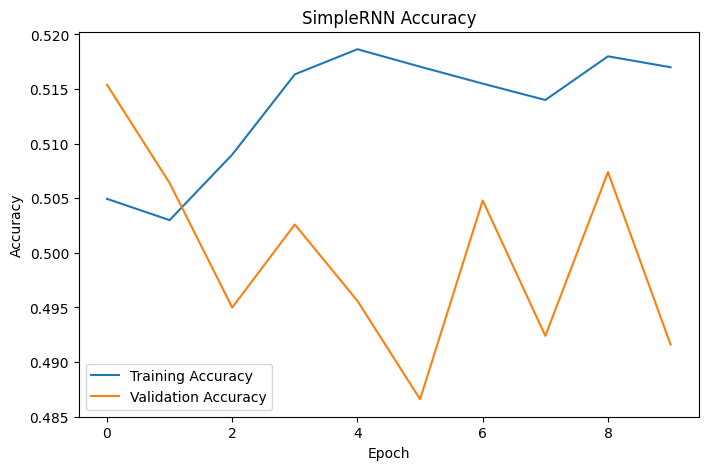

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("SimpleRNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [64]:
model_rnn.save("simple_rnn_model.h5")

##Task 4: Build LSTM Model

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [66]:
VOCAB_SIZE = 10000
MAX_LEN = 509

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(X_train.shape)
print(X_test.shape)

(25000, 509)
(25000, 509)


In [67]:
model_lstm = Sequential()

# Embedding Layer
model_lstm.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    )
)

# LSTM Layer
model_lstm.add(
    LSTM(
        units=64
    )
)

# Dense Layer
model_lstm.add(
    Dense(
        32,
        activation='relu'
    )
)

# Output Layer
model_lstm.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [68]:
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [69]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [70]:
import time

start = time.time()


history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

lstm_time = time.time() - start

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5024 - loss: 0.6930 - val_accuracy: 0.5066 - val_loss: 0.6929
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5177 - loss: 0.6852 - val_accuracy: 0.5158 - val_loss: 0.6908
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5336 - loss: 0.6622 - val_accuracy: 0.5174 - val_loss: 0.7222
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5390 - loss: 0.6464 - val_accuracy: 0.5152 - val_loss: 0.7193
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5443 - loss: 0.6387 - val_accuracy: 0.5144 - val_loss: 0.7515
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5463 - loss: 0.6378 - val_accuracy: 0.5446 - val_loss: 0.7831
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7444 - loss: 0.5184 - val_accuracy: 0.7910 - val_loss: 0.4982
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8791 - loss: 0.3169 - val_acc

In [71]:
loss_lstm, accuracy_lstm = model_lstm.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss_lstm)
print("Test Accuracy:", accuracy_lstm)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8580 - loss: 0.4123
Test Loss: 0.41228407621383667
Test Accuracy: 0.8579999804496765


In [72]:
y_pred_prob = model_lstm.predict(X_test)

y_pred_lstm = (
    y_pred_prob > 0.5
).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [73]:
print(
    classification_report(
        y_test,
        y_pred_lstm
    )
)

              precision    recall  f1-score   support

           0       0.88      0.83      0.85     12500
           1       0.84      0.88      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [74]:
cm = confusion_matrix(
    y_test,
    y_pred_lstm
)

print(cm)

[[10412  2088]
 [ 1462 11038]]


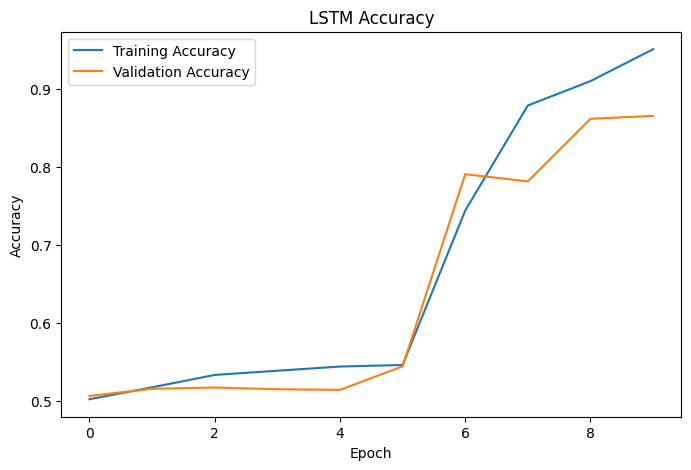

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

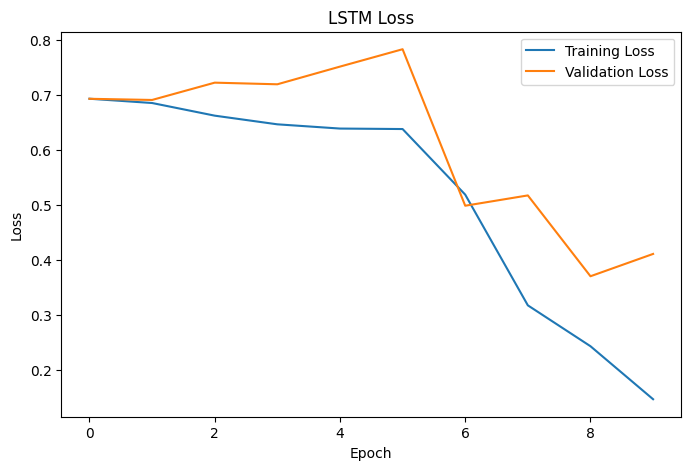

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [77]:
model_lstm.save("lstm_model.h5")

##Task 5: Build GRU Model

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [79]:
VOCAB_SIZE = 10000
MAX_LEN = 509

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (25000, 509)
Testing Shape : (25000, 509)


In [80]:
model_gru = Sequential()

# Embedding Layer
model_gru.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    )
)

# GRU Layer
model_gru.add(
    GRU(
        units=64
    )
)

# Dense Layer
model_gru.add(
    Dense(
        32,
        activation='relu'
    )
)

# Output Layer
model_gru.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [81]:
model_gru.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [82]:
model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [83]:
import time

start = time.time()
history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

gru_time = time.time() - start

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5026 - loss: 0.6930 - val_accuracy: 0.5074 - val_loss: 0.6932
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5188 - loss: 0.6861 - val_accuracy: 0.5072 - val_loss: 0.6963
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5303 - loss: 0.6606 - val_accuracy: 0.5094 - val_loss: 0.7204
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5368 - loss: 0.6431 - val_accuracy: 0.5126 - val_loss: 0.7539
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5913 - loss: 0.6226 - val_accuracy: 0.7592 - val_loss: 0.5795
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8777 - loss: 0.3079 - val_accuracy: 0.8806 - val_loss: 0.2941
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9527 - loss: 0.1406 - val_accuracy: 0.8838 - val_loss: 0.3182
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9807 - loss: 0.0705 - val_acc

In [84]:
loss_gru, accuracy_gru = model_gru.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss_gru)
print("Test Accuracy:", accuracy_gru)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8564 - loss: 0.5820
Test Loss: 0.5819940567016602
Test Accuracy: 0.8563600182533264


In [85]:
y_pred_prob = model_gru.predict(X_test)

y_pred_gru = (
    y_pred_prob > 0.5
).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [86]:
print(
    classification_report(
        y_test,
        y_pred_gru
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     12500
           1       0.87      0.84      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [87]:
cm = confusion_matrix(
    y_test,
    y_pred_gru
)

print(cm)

[[10967  1533]
 [ 2058 10442]]


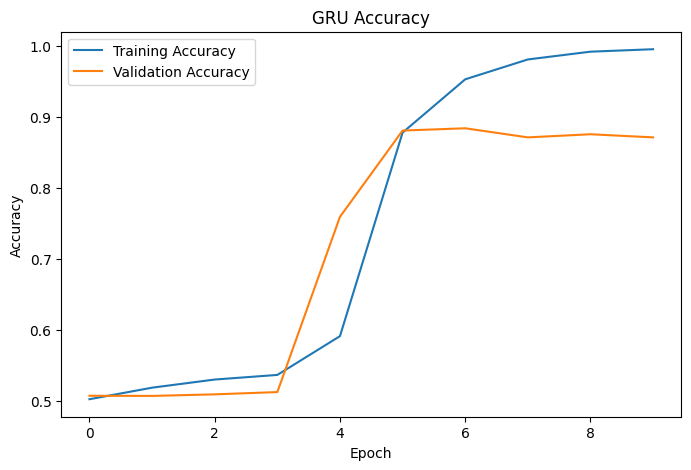

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_gru.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

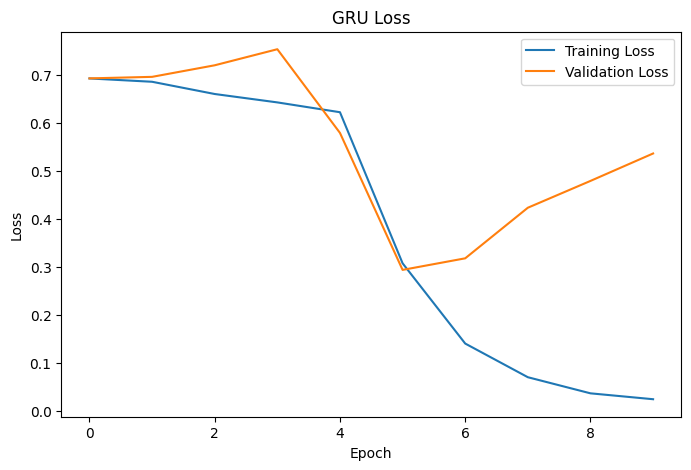

In [89]:
plt.figure(figsize=(8,5))

plt.plot(
    history_gru.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_gru.history['val_loss'],
    label='Validation Loss'
)

plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [90]:
model_gru.save("gru_model.h5")

##Task 6: Performance Comparison

In [91]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [92]:
rnn_accuracy = accuracy_score(y_test, y_pred_rnn)
rnn_precision = precision_score(y_test, y_pred_rnn)
rnn_recall = recall_score(y_test, y_pred_rnn)
rnn_f1 = f1_score(y_test, y_pred_rnn)

In [93]:
lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
lstm_precision = precision_score(y_test, y_pred_lstm)
lstm_recall = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

In [94]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
gru_precision = precision_score(y_test, y_pred_gru)
gru_recall = recall_score(y_test, y_pred_gru)
gru_f1 = f1_score(y_test, y_pred_gru)

In [95]:
rnn_params = model_rnn.count_params()
lstm_params = model_lstm.count_params()
gru_params = model_gru.count_params()

In [96]:
rnn_val_acc = max(history_rnn.history['val_accuracy'])
rnn_val_loss = min(history_rnn.history['val_loss'])

lstm_val_acc = max(history_lstm.history['val_accuracy'])
lstm_val_loss = min(history_lstm.history['val_loss'])

gru_val_acc = max(history_gru.history['val_accuracy'])
gru_val_loss = min(history_gru.history['val_loss'])

In [97]:
import pandas as pd

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'Training Time (sec)',
        'Validation Accuracy',
        'Validation Loss',
        'Parameters'
    ],

    'SimpleRNN': [
        rnn_accuracy,
        rnn_precision,
        rnn_recall,
        rnn_f1,
        rnn_time,
        rnn_val_acc,
        rnn_val_loss,
        rnn_params
    ],

    'LSTM': [
        lstm_accuracy,
        lstm_precision,
        lstm_recall,
        lstm_f1,
        lstm_time,
        lstm_val_acc,
        lstm_val_loss,
        lstm_params
    ],

    'GRU': [
        gru_accuracy,
        gru_precision,
        gru_recall,
        gru_f1,
        gru_time,
        gru_val_acc,
        gru_val_loss,
        gru_params
    ]
})

print(comparison)

                Metric     SimpleRNN          LSTM           GRU
0             Accuracy  5.001600e-01  8.580000e-01  8.563600e-01
1            Precision  5.000806e-01  8.409264e-01  8.719833e-01
2               Recall  9.924800e-01  8.830400e-01  8.353600e-01
3             F1 Score  6.650584e-01  8.614688e-01  8.532789e-01
4  Training Time (sec)  1.322378e+02  8.233001e+01  7.716961e+01
5  Validation Accuracy  5.154000e-01  8.658000e-01  8.838000e-01
6      Validation Loss  6.936795e-01  3.698834e-01  2.941186e-01
7           Parameters  1.294465e+06  1.331521e+06  1.319361e+06


##Task 7: Visualization

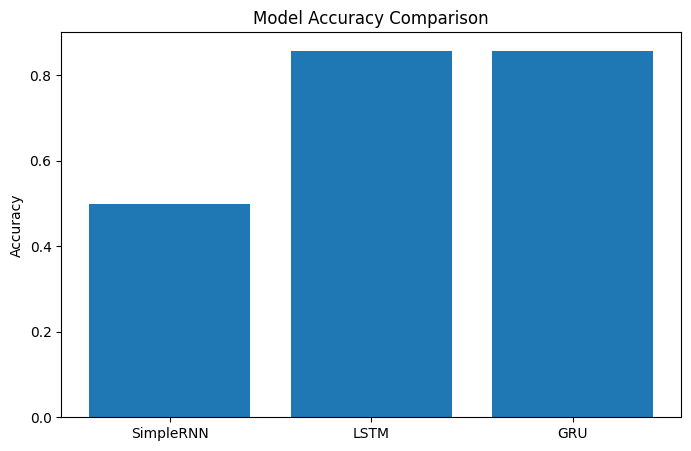

In [98]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

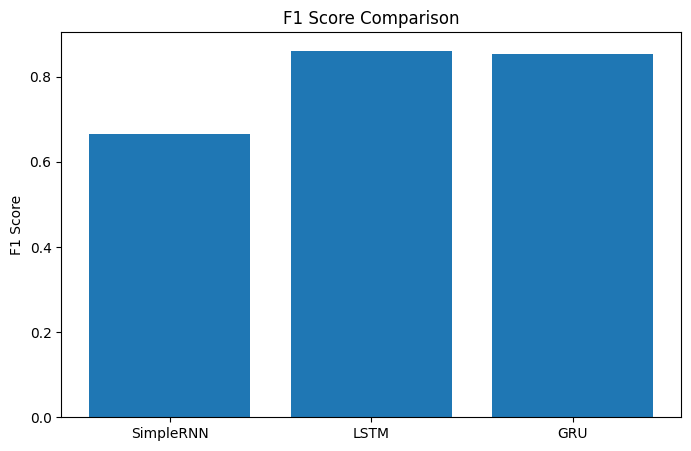

In [99]:
f1_scores = [
    rnn_f1,
    lstm_f1,
    gru_f1
]

plt.figure(figsize=(8,5))
plt.bar(models, f1_scores)

plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.show()

In [100]:
rnn_train_loss = history_rnn.history['loss'][-1]
rnn_val_loss = history_rnn.history['val_loss'][-1]

lstm_train_loss = history_lstm.history['loss'][-1]
lstm_val_loss = history_lstm.history['val_loss'][-1]

gru_train_loss = history_gru.history['loss'][-1]
gru_val_loss = history_gru.history['val_loss'][-1]

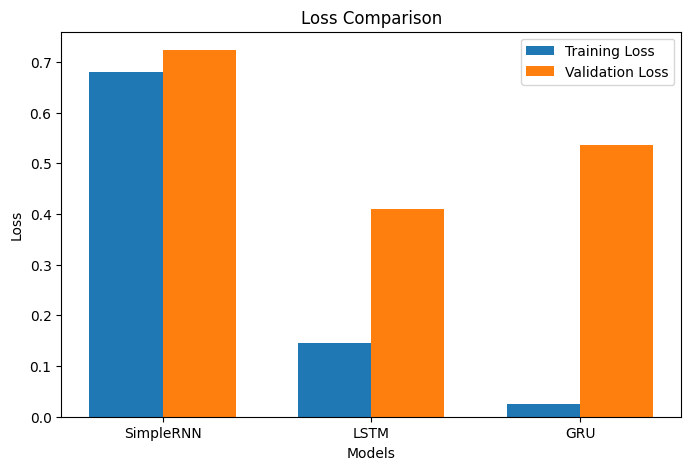

In [101]:
import numpy as np
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']

train_loss = [
    rnn_train_loss,
    lstm_train_loss,
    gru_train_loss
]

val_loss = [
    rnn_val_loss,
    lstm_val_loss,
    gru_val_loss
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    train_loss,
    width,
    label='Training Loss'
)

plt.bar(
    x + width/2,
    val_loss,
    width,
    label='Validation Loss'
)

plt.xticks(x, models)

plt.title("Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")

plt.legend()

plt.show()

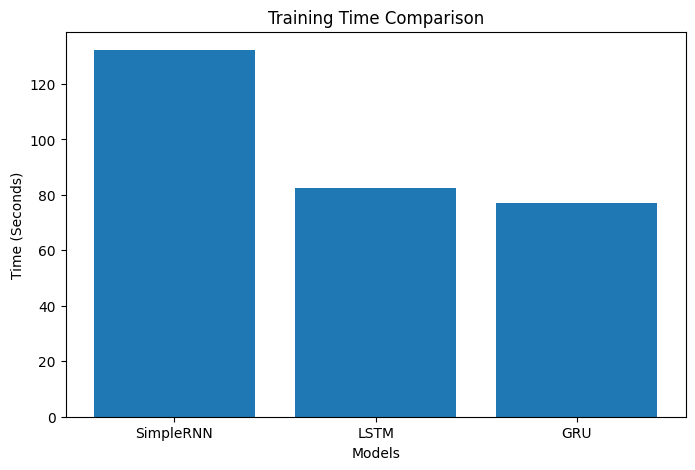

In [102]:
models = ['SimpleRNN', 'LSTM', 'GRU']

training_times = [
    rnn_time,
    lstm_time,
    gru_time
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    training_times
)

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (Seconds)")

plt.show()

##Task 8: Real-Time Testing

In [103]:
import numpy as np

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [104]:
from tensorflow.keras.models import load_model

model_rnn = load_model("simple_rnn_model.h5")
model_lstm = load_model("lstm_model.h5")
model_gru = load_model("gru_model.h5")

In [105]:
import re
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_review(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [106]:
VOCAB_SIZE = 10000
MAX_LEN = 509

def prepare_input(review):

    review = preprocess_review(review)

    sequence = tokenizer.texts_to_sequences(
        [review]
    )

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    return padded

In [107]:
def predict_sentiment(model, review):

    review_seq = prepare_input(review)

    probability = model.predict(
        review_seq,
        verbose=0
    )[0][0]

    sentiment = (
        "Positive"
        if probability >= 0.5
        else "Negative"
    )

    confidence = (
        probability * 100
        if probability >= 0.5
        else (1 - probability) * 100
    )

    return sentiment, confidence

In [108]:
review1 = """
This movie was absolutely fantastic
and I enjoyed every minute.
"""

review2 = """
The movie was boring and a complete
waste of time.
"""

review3 = """
The acting was good but the story
was average.
"""

In [109]:
reviews = [
    review1,
    review2,
    review3
]

models = {
    "SimpleRNN": model_rnn,
    "LSTM": model_lstm,
    "GRU": model_gru
}

for idx, review in enumerate(reviews, start=1):

    print("\n" + "="*60)
    print(f"Review {idx}")
    print(review)

    for name, model in models.items():

        sentiment, confidence = predict_sentiment(
            model,
            review
        )

        print(
            f"{name}: "
            f"{sentiment} "
            f"({confidence:.2f}%)"
        )


Review 1

This movie was absolutely fantastic
and I enjoyed every minute.

SimpleRNN: Positive (57.09%)
LSTM: Positive (55.89%)


GRU: Positive (99.56%)

Review 2

The movie was boring and a complete
waste of time.

SimpleRNN: Positive (57.09%)
LSTM: Negative (68.03%)
GRU: Negative (98.29%)

Review 3

The acting was good but the story
was average.

SimpleRNN: Positive (57.09%)
LSTM: Negative (75.59%)
GRU: Positive (87.88%)


In [110]:
import pandas as pd

results = []

for review_id, review in enumerate(reviews, start=1):

    for model_name, model in models.items():

        sentiment, confidence = predict_sentiment(
            model,
            review
        )

        results.append([
            review_id,
            model_name,
            sentiment,
            round(confidence, 2)
        ])

df = pd.DataFrame(
    results,
    columns=[
        "Review",
        "Model",
        "Sentiment",
        "Confidence (%)"
    ]
)

print(df)

   Review      Model Sentiment  Confidence (%)
0       1  SimpleRNN  Positive       57.090000
1       1       LSTM  Positive       55.889999
2       1        GRU  Positive       99.559998
3       2  SimpleRNN  Positive       57.090000
4       2       LSTM  Negative       68.029999
5       2        GRU  Negative       98.290001
6       3  SimpleRNN  Positive       57.090000
7       3       LSTM  Negative       75.589996
8       3        GRU  Positive       87.879997
